# ADNI Dataset

In [1]:
import os
import re
import torch
import operator
import numpy as np
import pandas as pd
import nibabel as nib
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET


from typing import Union, Any, Tuple, Dict
from sklearn.model_selection import train_test_split

In [2]:
BASE_PATH = "/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T"
TAB_PATH = os.path.join(BASE_PATH, "ADNI1_Annual_2_Yr_3T_metadata/ADNI")
IM_PATH = os.path.join(BASE_PATH, "ADNI1_Annual_2_Yr_3T/ADNI")
CSV_PATH = os.path.join(BASE_PATH, "ADNI1_Annual_2_Yr_3T_10_05_2025.csv")

In [3]:
img = nib.load("/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/ADNI1_Annual_2_Yr_3T/ADNI/023_S_0030/MPR__GradWarp__B1_Correction__N3__Scaled/2007-11-13_12_58_18.0/I87493/ADNI_023_S_0030_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080115173619365_S42714_I87493.nii")
data = img.get_fdata()

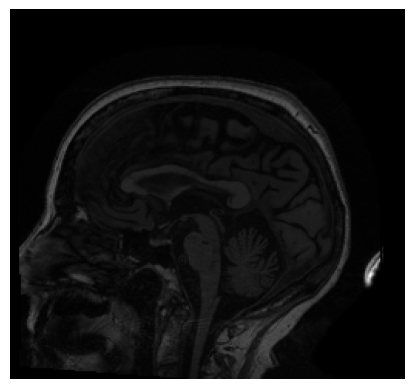

In [4]:
plt.imshow(data[:, :, data.shape[2] // 2], cmap="gray")
plt.axis("off")
plt.show()

In [5]:
def get_counts(df: pd.DataFrame, feature: str, split_value: float = -1.0) -> pd.DataFrame:
    
    if split_value != -1:
        below_or_equal = df[df[feature] <= split_value].shape[0]
        above = df[df[feature] > split_value].shape[0]
        total = below_or_equal + above
        summary = pd.DataFrame({
            'Count': [below_or_equal, above],
            'Percentage': [round(below_or_equal / total * 100, 3), round(above / total * 100, 3)]
        }, index=[f'≤ {split_value}', f'> {split_value}'])
        return summary
    
    counts = df[feature].value_counts()
    percentages = df[feature].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.round(3)
    })
    return summary

In [6]:
def plot_histogram_comparison(train: pd.Series, val: pd.Series, test: pd.Series, feature: str,bins: int = 50) -> None:
    plt.figure(figsize=(10, 6))

    # Plot histograms on the same axis
    plt.hist(train.dropna(), bins=bins//3,label='Train', color='blue', edgecolor='black', weights=np.ones(len(train)) * 100 / len(train))
    plt.hist(val.dropna(),   bins=bins//3,label='Val',   color='red', edgecolor='black', weights=np.ones(len(val)) * 100 / len(val))
    plt.hist(test.dropna(),  bins=bins, label='Test',  color='green', edgecolor='black', weights=np.ones(len(test)) * 100 / len(test))

    # Customize
    plt.title(f'{feature} Distribution', fontsize=18)
    plt.xlabel(feature, fontsize=16)
    plt.ylabel('% of split', fontsize=16)
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

In [7]:
def plot_distributions(df: pd.DataFrame, feature: str, highlight_dict: dict[int, str] = {}, misc_limit: int = 0, bins: int = 50) -> None:
    counts_df = get_counts(df=df, feature=feature)
    
    plt.figure(figsize=(10, 6))

    if len(counts_df) > 50:
        counts_df.sort_index(inplace=True)
        counts, bins_edges = np.histogram(counts_df.index, bins=bins)

        # Convert counts to percentage
        percentages = counts / counts.sum() * 100

        # Compute bin centers for correct alignment
        bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2
        bar_widths = np.diff(bins_edges)

        # Plot the histogram manually using bar
        plt.bar(bin_centers, percentages, width=bar_widths, align='center',
                alpha=0.5, label='Train', color='blue', edgecolor='black')
        plt.ylabel('Percentage %')

    else:
        # Step 1: Summarize entries below threshold
        low_count = counts_df[counts_df["Count"] < misc_limit]
        high_count = counts_df[counts_df["Count"] >= misc_limit]

        # Step 2: Add "Miscellaneous" as a new row
        misc_total = low_count["Count"].sum()
        misc_perc = low_count["Percentage"].sum()
        if misc_total > 0:
            misc_row = pd.DataFrame({"Count": [misc_total], "Percentage": [misc_perc]}, index=["Miscellaneous"])
            df_plot = pd.concat([high_count, misc_row])
        else:
            df_plot = high_count.copy()

        ## Step 3: Sort (optional)
        #df_plot = df_plot.sort_values(by="Count", ascending=False)

        # Step 4: Plot
        ax = df_plot["Count"].plot(kind='bar', color='skyblue', edgecolor='black', width=1)
        plt.ylabel('Frequency', fontsize=16)

        # Step 5: Highlight selected bars using the new index
        for i, label in enumerate(df_plot.index):
            if i in highlight_dict:
                ax.patches[i].set_facecolor(highlight_dict[i])
                
            if len(plt.gca().get_xticks()) > 50:
                plt.locator_params(axis='x', nbins=25)

    # Customize the plot
    plt.title(f'{feature} distribution', fontsize=18)
    plt.xlabel(feature, fontsize=16)
    plt.tight_layout()
    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)

    # Show the plot
    plt.show()

In [8]:
def calc_normalized_dists(count_df: pd.DataFrame) -> pd.DataFrame:
    return count_df['Count'] / count_df['Count'].sum()

In [9]:
def plot_compare_distribution(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, feature: str, feature_name: str) -> None:
    train_counts = get_counts(df=train_df, feature=feature)
    val_counts = get_counts(df=val_df, feature=feature)
    test_counts = get_counts(df=test_df, feature=feature)

    train_norm = calc_normalized_dists(count_df=train_counts)
    val_norm = calc_normalized_dists(count_df=val_counts)
    test_norm = calc_normalized_dists(count_df=test_counts)   
    
    train_pct = train_norm / train_norm.sum() * 100
    val_pct = val_norm / val_norm.sum() * 100
    test_pct = test_norm / test_norm.sum() * 100
    
    display(train_pct)
    display(val_pct)
    display(test_pct)
    
    plt.figure(figsize=(12, 6))
    plt.plot(feature, train_pct, label='Train', marker='o')
    plt.plot(feature, val_pct, label='Validation', marker='s')
    plt.plot(feature, test_pct, label='Test', marker='^')
    plt.xticks(rotation=45)
    
    plt.ylabel('% of split')
    plt.title(f'{feature_name} Distribution Comparison')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [10]:
def denormalize_column(df: pd.DataFrame, column: str, means: pd.Series, stds: pd.Series) -> pd.Series:
    mean = means[column]
    std = stds[column]
    col = df[column] * std + mean
    return col.reset_index(drop=True)

In [11]:
def plot_histogram_comparison(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, feature: str, bins: int = 50) -> None:
    plt.figure(figsize=(10, 6))

    # Plot histograms on the same axis
    plt.hist(train_df[feature].dropna(), bins=bins, label='Train', color='blue', edgecolor='black', weights=np.ones(len(train_df)) * 100 / len(train_df))
    plt.hist(val_df[feature].dropna(),   bins=bins, label='Val',   color='red', edgecolor='black', weights=np.ones(len(val_df)) * 100 / len(val_df))
    plt.hist(test_df[feature].dropna(),  bins=bins, label='Test',  color='green', edgecolor='black', weights=np.ones(len(test_df)) * 100 / len(test_df))

    # Customize
    plt.title(f'{feature} Distribution', fontsize=18)
    plt.xlabel(feature, fontsize=16)
    plt.ylabel('% of split', fontsize=16)
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

## Load Data

In [12]:
subjects = [i for i in os.listdir(TAB_PATH) if os.path.isdir(os.path.join(TAB_PATH, i))]

subject_metadata_dir = {k: [] for k in subjects}
for key in subject_metadata_dir.keys():
    for i in os.listdir(TAB_PATH):
        path = os.path.join(TAB_PATH, i)
        if not os.path.isfile(path):
            continue
        if key in path:
            subject_metadata_dir[key].append(path)
            
subject_image_dir = {k: "" for k in subjects}
for key in subject_image_dir.keys():
    for i in os.listdir(IM_PATH):
        path = os.path.join(IM_PATH, i)
        if not os.path.isdir(path):
            continue
        if key in path:
            subject_image_dir[key] = path

In [13]:
def get_leaf_directories(root_dir):
    leaf_dirs = []
    root_dir = root_dir if isinstance(root_dir, list) else [root_dir]
    for root in root_dir:
        for dirpath, dirnames, filenames in os.walk(root):
            if not dirnames:  # no subdirectories → it's a leaf
                leaf_dirs.append(dirpath)
    return leaf_dirs

def get_files(dir):
    return [os.path.join(dir, f) for f in os.listdir(dir) if os.path.isfile(os.path.join(dir, f))]

subject_image_ids_dir = {k: get_leaf_directories(v) for k, v in subject_image_dir.items()}
subject_image_ids = {k: [os.path.basename(path) for path in v] for k, v in subject_image_ids_dir.items()}

subject_dict_list = []
for sub in subjects:
    new_dict: dict[str, Any] = {"subject_id": sub}
    new_dict["data"] = []
    for ids in subject_image_ids[sub]:
        id_metapath = [s for s in subject_metadata_dir[sub] if ids in s][0]
        id_image = [im for im in get_leaf_directories(subject_image_ids_dir[sub]) if ids in im][0]
        id_image = get_files(id_image)[0]
        new_dict["data"].append({"tab_path": id_metapath, "image_path": id_image, "id": ids})
    subject_dict_list.append(new_dict)
        
subject_dict_list

[{'subject_id': '130_S_0449',
  'data': [{'tab_path': '/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/ADNI1_Annual_2_Yr_3T_metadata/ADNI/ADNI_130_S_0449_MPR-R____N3__Scaled_S18012_I81434.xml',
    'image_path': '/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/ADNI1_Annual_2_Yr_3T/ADNI/130_S_0449/MPR-R____N3__Scaled/2006-08-16_10_41_17.0/I81434/ADNI_130_S_0449_MR_MPR-R____N3__Scaled_Br_20071110121628197_S18012_I81434.nii',
    'id': 'I81434'},
   {'tab_path': '/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/ADNI1_Annual_2_Yr_3T_metadata/ADNI/ADNI_130_S_0449_MPR____N3__Scaled_S38619_I82686.xml',
    'image_path': '/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/ADNI1_Annual_2_Yr_3T/ADNI/130_S_0449/MPR____N3__Scaled/2007-08-27_10_30_19.0/I82686/ADNI_130_S_0449_MR_MPR____N3__Scaled_Br_20071119102143821_S38619_I82686.nii',
    'id': 'I82686'},
   {'tab_path': '/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/ADNI1_Annual_2_Yr_3T_metadata/ADNI/ADNI_130_S_0449_MP

In [14]:
def parse_ida_xml_to_dataframe(xml_path: str) -> pd.DataFrame:
    """
    Parse an IDA XML file (like ADNI structure) into a flat pandas DataFrame.
    - Handles mixed namespaces automatically.
    - Produces one row per subject/visit/study combination.
    - Assessment scores and subjectInfo entries become columns.
    """
    # --- Load XML and strip namespaces ---
    with open(xml_path, "r", encoding="utf-8") as f:
        xml_text = f.read()

    xml_text = re.sub(r'\sxmlns(:\w+)?="[^"]+"', '', xml_text)
    xml_text = re.sub(r'xsi:[a-zA-Z]+="[^"]+"', '', xml_text)

    root = ET.fromstring(xml_text)

    records = []

    for project in root.findall(".//project"):
        project_id = project.findtext("projectIdentifier")
        project_desc = project.findtext("projectDescription")
        site_key = project.findtext("siteKey")

        for subject in project.findall(".//subject"):
            subj_id = subject.findtext("subjectIdentifier")
            group = subject.findtext("researchGroup")
            sex = subject.findtext("subjectSex")

            # --- Gather <subjectInfo> key-value pairs ---
            subject_info = {}
            for info in subject.findall(".//subjectInfo"):
                key = info.get("item")
                val = info.text
                if key:
                    subject_info[key] = val

            # --- Study info ---
            for study in subject.findall(".//study"):
                study_id = study.findtext("studyIdentifier")
                subj_age = study.findtext("subjectAge")
                weight = study.findtext("weightKg")
                postmortem = study.findtext("postMortem")

                for series in study.findall(".//series"):
                    series_id = series.findtext("seriesIdentifier")
                    modality = series.findtext("modality")
                    date_acq = series.findtext("dateAcquired")

                    base_record = {
                        "projectIdentifier": project_id,
                        "projectDescription": project_desc,
                        "siteKey": site_key,
                        "subjectIdentifier": subj_id,
                        "researchGroup": group,
                        "subjectSex": sex,
                        "studyIdentifier": study_id,
                        "subjectAge": subj_age,
                        "weightKg": weight,
                        "postMortem": postmortem,
                        "seriesIdentifier": series_id,
                        "modality": modality,
                        "dateAcquired": date_acq,
                    }

                    # Add subjectInfo values as columns
                    base_record.update(subject_info)

                    # --- Visits and Assessments ---
                    for visit in subject.findall(".//visit"):
                        visit_id = visit.findtext("visitIdentifier")
                        record = base_record.copy()
                        record["visitIdentifier"] = visit_id

                        # Collect assessments into columns
                        for assessment in visit.findall(".//assessment"):
                            for component in assessment.findall(".//component"):
                                score_elem = component.find(".//assessmentScore")
                                if score_elem is not None:
                                    score_attr = score_elem.get("attribute")
                                    score_value = score_elem.text
                                    record[score_attr] = score_value

                        records.append(record)

    df = pd.DataFrame(records)
    df = df.drop_duplicates()

    return df

In [15]:
def get_tabular_data(dict_list):
    df_full = pd.DataFrame()
    for d in dict_list:
        for point in d["data"]:
            path = point["tab_path"]
            df = parse_ida_xml_to_dataframe(path)
            df["im_path"] = point["image_path"]
            df["dataIdentifier"] = df["subjectIdentifier"] + "_" + df["studyIdentifier"]
            if df_full.empty:
                df_full = df
            else:
                df_full = pd.concat([df_full, df])
    return df_full.reset_index(drop=True)
                
tab_data = get_tabular_data(dict_list=subject_dict_list)
tab_data

,projectIdentifier,projectDescription,siteKey,subjectIdentifier,researchGroup,subjectSex,studyIdentifier,subjectAge,weightKg,postMortem,...,APOE A1,APOE A2,visitIdentifier,NPISCORE,FAQTOTAL,im_path,dataIdentifier,MMSCORE,GDTOTAL,CDGLOBAL
0,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,4893,66.8466,58.06,F,...,4,4,ADNI Baseline,0.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,130_S_0449_4893,NaN,NaN,NaN
1,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,11625,67.8767,56.7,F,...,4,4,ADNI1/GO Month 12,1.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,130_S_0449_11625,27.0,2.0,0.5
2,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,17355,68.8356,60.78,F,...,4,4,ADNI1/GO Month 24,3.0,11.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,130_S_0449_17355,29.0,1.0,0.5
3,ADNI,Alzheimer's Disease Neuroimaging Initiative,116,116_S_0382,CN,F,4239,75.6986,63.73,F,...,3,3,ADNI Baseline,0.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,116_S_0382_4239,NaN,NaN,NaN
4,ADNI,Alzheimer's Disease Neuroimaging Initiative,116,116_S_0382,CN,F,9326,76.6986,63.5,F,...,3,3,ADNI1/GO Month 12,0.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,116_S_0382_9326,29.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,ADNI,Alzheimer's Disease Neuroimaging Initiative,023,023_S_0331,MCI,F,3502,64.7178,66.22,F,...,4,4,ADNI Baseline,3.0,9.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,023_S_0331_3502,NaN,NaN,NaN
302,ADNI,Alzheimer's Disease Neuroimaging Initiative,136,136_S_0429,MCI,M,4278,62.8384,84.37,F,...,3,3,ADNI Baseline,1.0,2.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,136_S_0429_4278,NaN,NaN,NaN
303,ADNI,Alzheimer's Disease Neuroimaging Initiative,136,136_S_0429,MCI,M,16449,64.8137,79.38,F,...,3,3,ADNI1/GO Month 24,2.0,4.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,136_S_0429_16449,25.0,6.0,0.5
304,ADNI,Alzheimer's Disease Neuroimaging Initiative,136,136_S_0429,MCI,M,4278,62.8384,84.37,F,...,3,3,ADNI Baseline,1.0,2.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,136_S_0429_4278,NaN,NaN,NaN


In [16]:
df_no_nan = tab_data.dropna()
df_no_nan

,projectIdentifier,projectDescription,siteKey,subjectIdentifier,researchGroup,subjectSex,studyIdentifier,subjectAge,weightKg,postMortem,...,APOE A1,APOE A2,visitIdentifier,NPISCORE,FAQTOTAL,im_path,dataIdentifier,MMSCORE,GDTOTAL,CDGLOBAL
1,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,11625,67.8767,56.7,F,...,4,4,ADNI1/GO Month 12,1.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,130_S_0449_11625,27.0,2.0,0.5
2,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,17355,68.8356,60.78,F,...,4,4,ADNI1/GO Month 24,3.0,11.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,130_S_0449_17355,29.0,1.0,0.5
4,ADNI,Alzheimer's Disease Neuroimaging Initiative,116,116_S_0382,CN,F,9326,76.6986,63.5,F,...,3,3,ADNI1/GO Month 12,0.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,116_S_0382_9326,29.0,1.0,0.0
5,ADNI,Alzheimer's Disease Neuroimaging Initiative,116,116_S_0382,CN,F,16134,77.6575,63.5,F,...,3,3,ADNI1/GO Month 24,2.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,116_S_0382_16134,29.0,1.0,0.0
7,ADNI,Alzheimer's Disease Neuroimaging Initiative,023,023_S_1190,CN,F,19390,78.6658,60.51,F,...,3,3,ADNI1/GO Month 24,1.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,023_S_1190_19390,30.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,ADNI,Alzheimer's Disease Neuroimaging Initiative,023,023_S_0331,MCI,F,7707,65.6521,63.68,F,...,4,4,ADNI1/GO Month 12,0.0,2.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,023_S_0331_7707,24.0,2.0,0.5
299,ADNI,Alzheimer's Disease Neuroimaging Initiative,023,023_S_0331,MCI,F,15218,66.6795,64.5,F,...,4,4,ADNI1/GO Month 24,1.0,3.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,023_S_0331_15218,26.0,1.0,0.5
300,ADNI,Alzheimer's Disease Neuroimaging Initiative,023,023_S_0331,MCI,F,7707,65.6521,63.68,F,...,4,4,ADNI1/GO Month 12,0.0,2.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,023_S_0331_7707,24.0,2.0,0.5
303,ADNI,Alzheimer's Disease Neuroimaging Initiative,136,136_S_0429,MCI,M,16449,64.8137,79.38,F,...,3,3,ADNI1/GO Month 24,2.0,4.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,136_S_0429_16449,25.0,6.0,0.5


In [17]:
relevant_cols = ["dataIdentifier", "subjectIdentifier", "researchGroup", "subjectSex", "subjectAge", "weightKg", "NPISCORE", "FAQTOTAL", "im_path", "MMSCORE", "GDTOTAL", "CDGLOBAL", "APOE A1", "APOE A2"]

relevant_df = df_no_nan[relevant_cols].reset_index(drop=True)

# possible labels
# CN: cognitively normal
# MCI: mild cognitive impairment
# AD: Alzheimer's disease
relevant_df["researchGroup"].unique()

array(['MCI', 'CN', 'AD'], dtype=object)

In [18]:
def fix_dtypes(df: pd.DataFrame, dtypes: dict[str, str]) -> pd.DataFrame:
    for col, dtype in dtypes.items():
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in DataFrame, skipping.")
            continue
        
        try:
            # Special case for datetime
            if "datetime" in dtype:
                df[col] = pd.to_datetime(df[col], errors="coerce")
            else:
                df[col] = df[col].astype(dtype)
        except Exception as e:
            print(f"Could not convert column '{col}' to {dtype}: {e}")
    
    return df

In [19]:
relevant_df

,dataIdentifier,subjectIdentifier,researchGroup,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,im_path,MMSCORE,GDTOTAL,CDGLOBAL,APOE A1,APOE A2
0,130_S_0449_11625,130_S_0449,MCI,F,67.8767,56.7,1.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,27.0,2.0,0.5,4,4
1,130_S_0449_17355,130_S_0449,MCI,F,68.8356,60.78,3.0,11.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,29.0,1.0,0.5,4,4
2,116_S_0382_9326,116_S_0382,CN,F,76.6986,63.5,0.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,29.0,1.0,0.0,3,3
3,116_S_0382_16134,116_S_0382,CN,F,77.6575,63.5,2.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,29.0,1.0,0.0,3,3
4,023_S_1190_19390,023_S_1190,CN,F,78.6658,60.51,1.0,0.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,30.0,1.0,0.0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,023_S_0331_7707,023_S_0331,MCI,F,65.6521,63.68,0.0,2.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,24.0,2.0,0.5,4,4
178,023_S_0331_15218,023_S_0331,MCI,F,66.6795,64.5,1.0,3.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,26.0,1.0,0.5,4,4
179,023_S_0331_7707,023_S_0331,MCI,F,65.6521,63.68,0.0,2.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,24.0,2.0,0.5,4,4
180,136_S_0429_16449,136_S_0429,MCI,M,64.8137,79.38,2.0,4.0,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...,25.0,6.0,0.5,3,3


In [20]:
correct_dtypes = {"dataIdentifier": "string", "subjectIdentifier": "string", "researchGroup": "string", "subjectSex": "string",
                  "subjectAge": "float64", "weightKg": "float64", "NPISCORE": "float64", "FAQTOTAL": "float64", "im_path": "string",
                  "MMSCORE": "float64", "GDTOTAL": "float64", "CDGLOBAL": "float64", "APOE A1": "int64", "APOE A2": "int64"}
relevant_df = fix_dtypes(df=relevant_df, dtypes=correct_dtypes)

In [21]:
relevant_df.dtypes

dataIdentifier        string
subjectIdentifier     string
researchGroup         string
subjectSex            string
subjectAge           float64
weightKg             float64
NPISCORE             float64
FAQTOTAL             float64
im_path               string
MMSCORE              float64
GDTOTAL              float64
CDGLOBAL             float64
APOE A1                int64
APOE A2                int64
dtype: object

In [22]:
relevant_df.loc[relevant_df["NPISCORE"].idxmin()]

dataIdentifier                                         116_S_0382_9326
subjectIdentifier                                           116_S_0382
researchGroup                                                       CN
subjectSex                                                           F
subjectAge                                                     76.6986
weightKg                                                          63.5
NPISCORE                                                           0.0
FAQTOTAL                                                           0.0
im_path              /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...
MMSCORE                                                           29.0
GDTOTAL                                                            1.0
CDGLOBAL                                                           0.0
APOE A1                                                              3
APOE A2                                                              3
Name: 

In [23]:
def get_slice(path):
    img = nib.load(path)
    data = img.get_fdata()
    slice = data[:, :, data.shape[2] // 2]
    slice_norm = (slice - np.min(slice)) / (np.max(slice) - np.min(slice))
    slice_uint8 = (slice_norm * 255).astype(np.uint8)
    return slice_uint8

def get_png_path(path: str, dir: str):
    return os.path.join(dir, os.path.basename(path)[:-3] + "png")
    
def save_image(series: pd.Series, dir: str):
    for row in series:
        png_path = get_png_path(path=row, dir=dir)
        img = get_slice(path=row)
        # Save as PNG
        if not os.path.exists(png_path):
            imageio.imwrite(png_path, img)

processed_path = os.path.join(BASE_PATH, "processed_data")
save_image(series=relevant_df["im_path"], dir=processed_path)

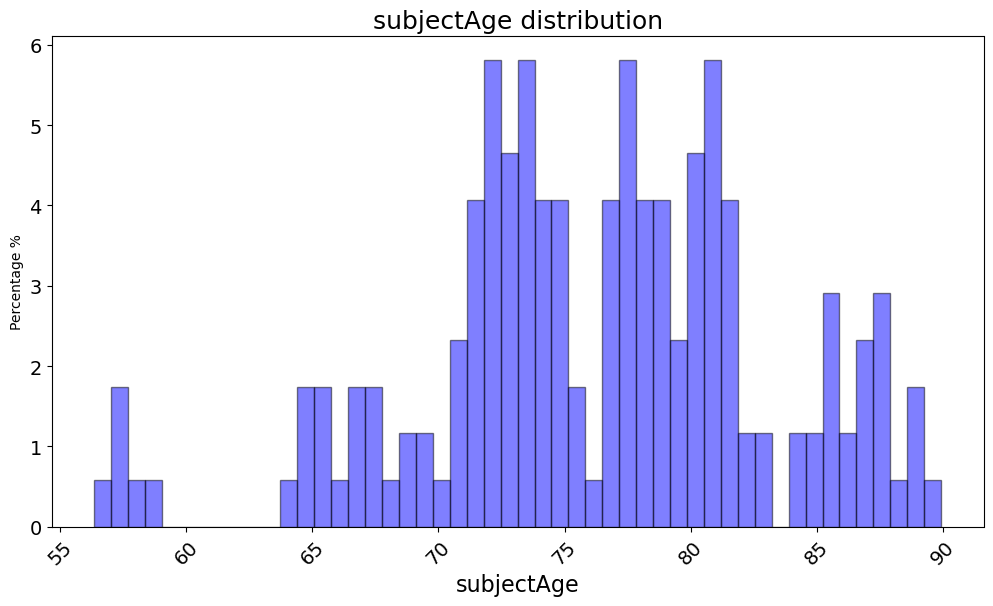

In [24]:
plot_distributions(df=relevant_df, feature="subjectAge")

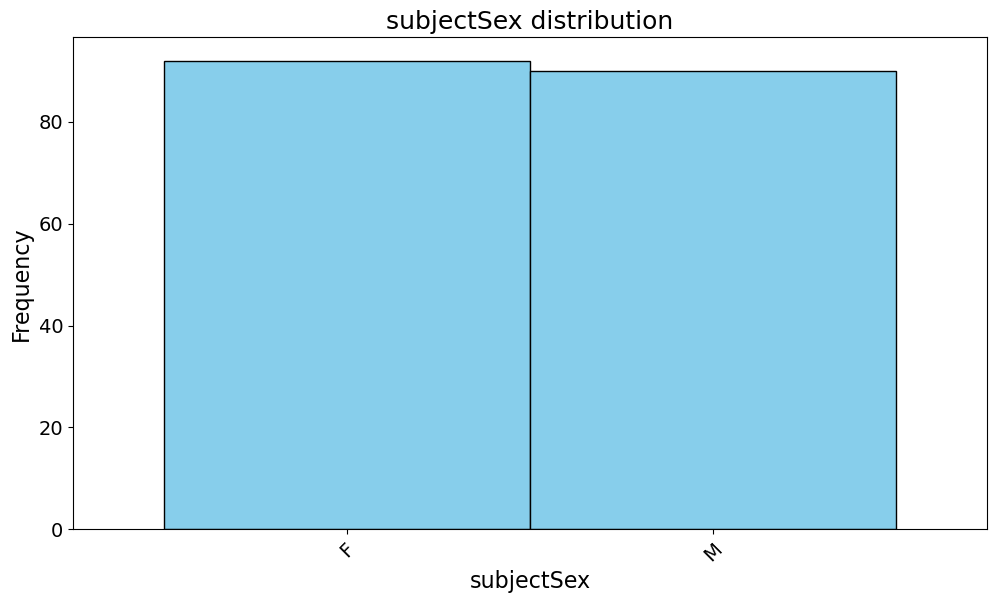

In [25]:
plot_distributions(df=relevant_df, feature="subjectSex")

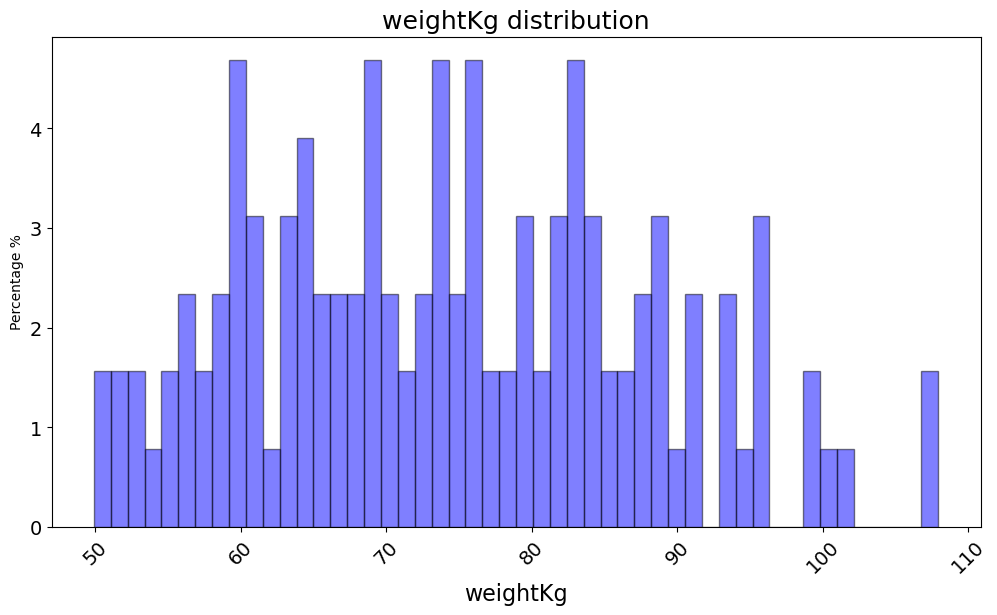

In [26]:
plot_distributions(df=relevant_df, feature="weightKg")

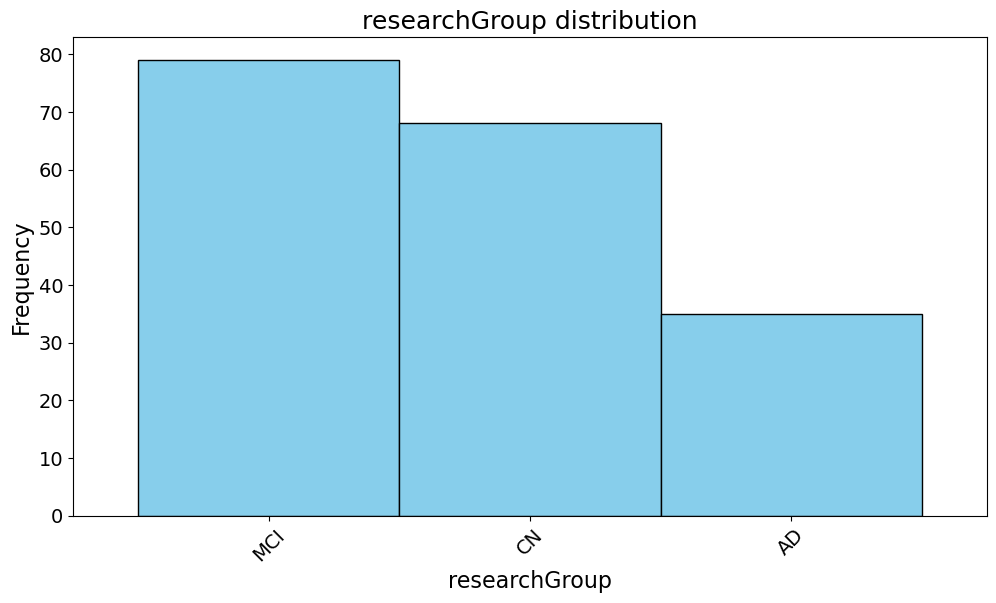

In [27]:
plot_distributions(df=relevant_df, feature="researchGroup")

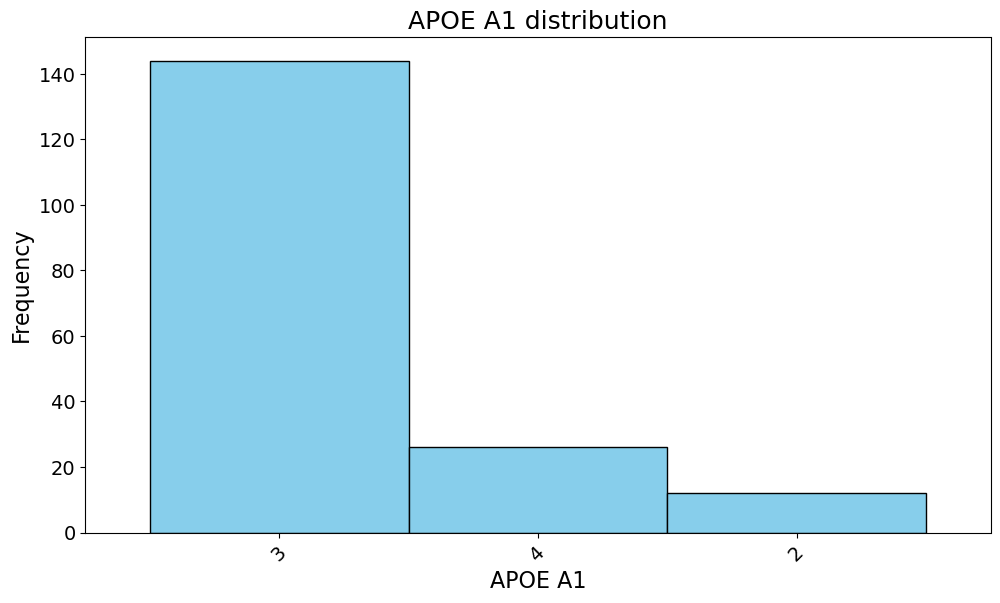

In [28]:
plot_distributions(df=relevant_df, feature="APOE A1")

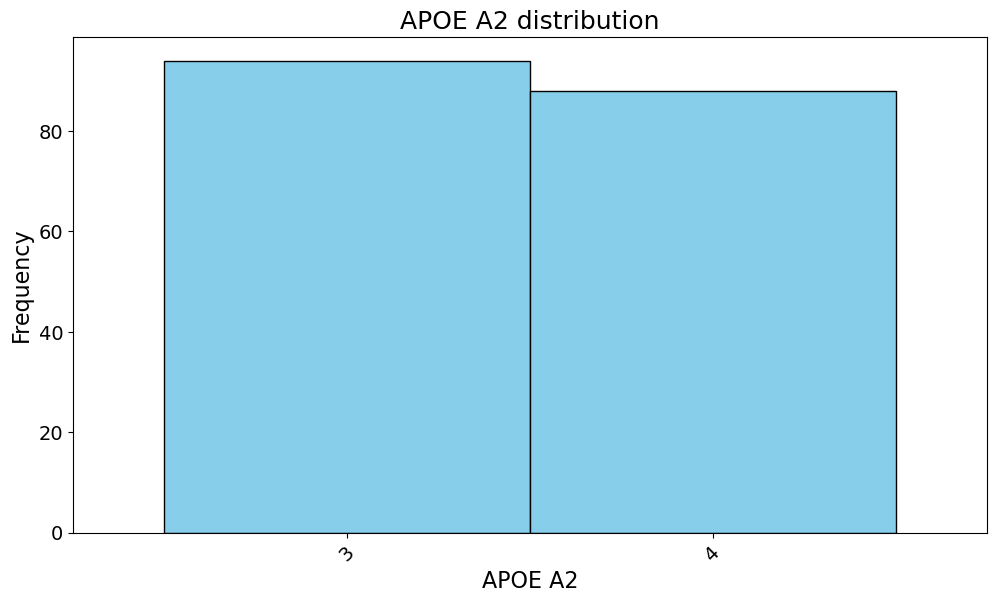

In [29]:
plot_distributions(df=relevant_df, feature="APOE A2")

## Split Data

In [30]:
def create_shift_mask(df: pd.DataFrame, filters: list[Dict[str, str]], filter_cond: str, con_columns: list[str], cat_columns: list[str]) -> pd.Series:
    first_bool = True if filter_cond == "and" else False
    
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        ">": operator.gt,
        ">=": operator.ge,
        "<": operator.lt,
        "<=": operator.le,
    }

    mask = pd.Series(first_bool, index=df.index)
    for f in filters:
        for col, val in f.items():
            if col in con_columns:
                if isinstance(val, tuple):
                    op_str, threshold = val
                    mask &= ops[op_str](df[col], threshold)
                else:
                    mask &= df[col] == val
            elif col in cat_columns:
                if isinstance(val, tuple):
                    op_str, threshold = val
                    mask |= ops[op_str](df[col], threshold)
                else:
                    mask |= df[col] == val
                    
    return mask

In [31]:
def data_split(df: pd.DataFrame, nclasses: int, split: Union[float, int]) -> np.ndarray:
  top_classes = df['researchGroup'].value_counts().nlargest(nclasses).index
  df = df[df['researchGroup'].isin(top_classes)].copy()
  
  critical_ids = df.groupby('researchGroup', as_index=False).head(n=1)['dataIdentifier']
  other_ids = df.loc[~df['dataIdentifier'].isin(critical_ids)]['dataIdentifier'].values

  if isinstance(split, float):
    to_fill_size = (int(len(df)*split)-len(critical_ids))
  elif isinstance(split, int):
    to_fill_size = split - len(critical_ids)

  if to_fill_size > 0:
    _, low_data_ids = train_test_split(other_ids, test_size=to_fill_size, random_state=2023)
  else:
    low_data_ids = []
  new_ids = np.concatenate([critical_ids,low_data_ids])
  
  new_first_df = df.loc[df['dataIdentifier'].isin(new_ids)]
  new_second_df = df.loc[~df['dataIdentifier'].isin(new_ids)]
  common_subjects = [i for i in new_first_df["subjectIdentifier"].unique() if i in new_second_df["subjectIdentifier"].unique()]
  
  move_first_cond = new_first_df["subjectIdentifier"].isin(common_subjects[:len(common_subjects)//2])
  move_first_rows = new_first_df[move_first_cond]
  new_second_df = pd.concat([new_second_df, move_first_rows], ignore_index=True)  
  new_first_df = new_first_df[~move_first_cond]
  
  move_second_cond = new_second_df["subjectIdentifier"].isin(common_subjects[len(common_subjects)//2:])
  move_second_rows = new_second_df[move_second_cond]
  
  new_first_df = pd.concat([new_first_df, move_second_rows], ignore_index=True)  
  new_second_df = new_second_df[~move_second_cond]


  return new_first_df["dataIdentifier"].values

In [32]:
def create_cutted_split(df: pd.DataFrame, size: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    nclasses = df["researchGroup"].nunique()
    df_ids = data_split(df=df, nclasses=nclasses, split=size)
    first_df = df.loc[df['dataIdentifier'].isin(df_ids)]
    second_df = df.loc[~df['dataIdentifier'].isin(df_ids)]
    return first_df.reset_index(drop=True), second_df.reset_index(drop=True)

In [33]:
def create_dataset(tab_data: pd.DataFrame, train_ratio: float, val_ratio: float):
    train_val, test = create_cutted_split(df=tab_data, size=train_ratio+val_ratio)
    val_size_relative = val_ratio / (train_ratio + val_ratio)
    train, val = create_cutted_split(df=train_val, size=1 - val_size_relative)
    return train, val, test

In [34]:
def categorize(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, categorical_columns: list[str]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str, dict]]:
    # Deep copies to ensure no slice/view issues
    train_df_copy = train_df.copy(deep=True)
    val_df_copy = val_df.copy(deep=True)
    test_df_copy = test_df.copy(deep=True)
    
    category_mappings = {}

    for col in categorical_columns:
        # Combine all categories
        all_categories = pd.Index(
            pd.concat([
                train_df_copy[col],
                val_df_copy[col],
                test_df_copy[col]
            ]).dropna().unique()
        )
        
        # Store the mapping
        mapping = {category: code for code, category in enumerate(all_categories)}
        category_mappings[col] = mapping

        # Assign categories
        for df in (train_df_copy, val_df_copy, test_df_copy):
            df[col] = pd.Categorical(df[col], categories=all_categories)
            df[col] = df[col].cat.codes

    return train_df_copy, val_df_copy, test_df_copy, category_mappings

In [35]:
def normalize(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, continuous_columns: list[str]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    # Compute mean and std from training set only
    mean = train_df[continuous_columns].mean()
    std = train_df[continuous_columns].std()
    
    non_constant_columns = std[std != 0].index.tolist()

    # Update mean and std
    mean = mean[non_constant_columns]
    std = std[non_constant_columns]

    # use copies for more sanitary workflow
    train_df_copy = train_df.copy()
    val_df_copy = val_df.copy()
    test_df_copy = test_df.copy()

    # Apply normalization using training stats
    train_df_copy[non_constant_columns] = (train_df_copy[non_constant_columns] - mean) / std
    val_df_copy[non_constant_columns] = (val_df_copy[non_constant_columns] - mean) / std
    test_df_copy[non_constant_columns] = (test_df_copy[non_constant_columns] - mean) / std

    return train_df_copy, val_df_copy, test_df_copy, mean, std

In [36]:
def reorder_df(df: pd.DataFrame, new_order: list[str]) -> pd.DataFrame:
    other_columns = list(set(list(df.columns)) - set(new_order))
    
    new_order = new_order + other_columns
    return df[new_order]

In [37]:
def get_lengths(df_list: list[pd.DataFrame], continuous_columns: list[str], categorical_columns: list[str]) -> Dict[str, int]:
    continuous_length = {i: 1 for i in continuous_columns}
    
    max_list = {i: 0 for i in categorical_columns}
    for df in df_list:
        for col in categorical_columns:
            df_col_max = df[col].max()
            max_list[col] = df_col_max if df_col_max > max_list[col] else max_list[col]
            
    max_list = {k: v+1 for k, v in max_list.items()}
    
    return max_list | continuous_length 

In [38]:
def save_dataset(df: pd.DataFrame, save_directory: str, split: str, keep_cols: list[str], image_dir: str) -> None:
    labels_path = f"labels_{split}.pt"
    labels_path = os.path.join(save_directory, labels_path)
    labels = list(df["researchGroup"].reset_index(drop=True))
    if not os.path.exists(labels_path):
        torch.save(labels, labels_path)
        print(f"Saved labels to {labels_path}")
    
    
    img_path = f"image_paths_{split}.pt"
    img_path = os.path.join(save_directory, img_path)
    imgs = df["im_path"].reset_index(drop=True)
    image_paths = [get_png_path(path=im, dir=image_dir) for im in imgs]
    if not os.path.exists(img_path):
        torch.save(image_paths, img_path)
        print(f"Saved image paths to {img_path}")
    
    adni_features_path = f"adni_features_{split}.csv"
    adni_features_path = os.path.join(save_directory, adni_features_path)
    data_df = df[keep_cols].reset_index(drop=True)
    if not os.path.exists(adni_features_path):
        data_df.to_csv(path_or_buf=adni_features_path, index=False, header=False)
        print(f"Saved ADNI Features to {adni_features_path}")

In [39]:
def save_lengths(lengths: Dict[str, int], file_name: str, save_directory: str) -> None:
    # save lengths list
    lengths_list = list(lengths.values())
    lengths_path = os.path.join(save_directory, file_name)
    if not os.path.exists(lengths_path):
        torch.save(lengths_list, lengths_path)
        print(f"Saved lengths to {lengths_path}")

In [40]:
def get_num_of_classes(df_list: list[pd.DataFrame], class_col: str) -> int:
    concat_df = pd.concat(df_list, axis=0)
    return concat_df[class_col].nunique()

In [41]:
def create_shifted_splits(df: pd.DataFrame, split: list[Dict[str, Any]], split_cond: str, ratio: list[int], con_columns: list[str], cat_columns: list[str], mode: int = 0) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    '''
    Creates shifted versions of the given DataFrames.
    
    
    Args:
    -----
        df (pd.DataFrame): the original df
        split (list[Dict[str, str]]): The elements that needs to be filtered
        ratio (list[int]): Expects a list containing three integer numbers:
                                first: train size
                                second: validation size
                                third: test size
        mode (int): The mode, i.e. if the newly generated test df should contain all split elements and train/val contain everything else (mode==0) or vice versa (mode==1) 
    '''
    mask = create_shift_mask(df=df, filters=split, filter_cond=split_cond, con_columns=con_columns, cat_columns=cat_columns)
    
    no_df = df[~mask]
    only_df = df[mask]
    
    test_df = pd.DataFrame()
    train_val_df = pd.DataFrame()
    if mode == 0:
        test_df = only_df
        train_val_df = no_df
    elif mode == 1:
        test_df = no_df
        train_val_df = only_df
    else:
        raise ValueError("mode can only be 0 or 1.")
    

    desired_test_size = min(ratio[2], test_df.shape[0])
    if desired_test_size != test_df.shape[0]:
        test_df, _ = create_cutted_split(df=test_df, size=desired_test_size)
    
    desired_train_val_size = min(ratio[0] + ratio[1], train_val_df.shape[0])
    if desired_train_val_size != train_val_df.shape[0]:
        train_val_df, _ = create_cutted_split(df=train_val_df, size=desired_train_val_size)
    
    common_ids = [i for i in train_val_df["subjectIdentifier"].unique() if i in test_df["subjectIdentifier"].unique()]

    train_val_df = train_val_df[~train_val_df["subjectIdentifier"].isin(common_ids)].reset_index(drop=True)

    desired_val_size = ratio[1]
    val_ids = data_split(df=train_val_df, nclasses=train_val_df["researchGroup"].nunique(), split=desired_val_size)
    
    val_df = train_val_df.loc[train_val_df['dataIdentifier'].isin(val_ids)]
    train_df = train_val_df.loc[~train_val_df['dataIdentifier'].isin(val_ids)]
    
    print(f"Shape of train df:\t{train_df.shape}")
    print(f"Shape of val df:\t{val_df.shape}")
    print(f"Shape of test df:\t{test_df.shape}")
    total_size = train_df.shape[0] + val_df.shape[0] + test_df.shape[0]
    print(f"Total Size: {total_size}")
    print(f"Ratio -> Train: {round(train_df.shape[0] / total_size, 2)} | Val: {round(val_df.shape[0] / total_size, 2)} | Test: {round(test_df.shape[0] / total_size, 2)}")

    return train_df, val_df, test_df

In [42]:
def save_new_datasets(train: pd.DataFrame, val: pd.DataFrame, test: pd.DataFrame, cat_cols: list[str], con_cols: list[str], save_directory: str, image_directory: str):
    train_df, val_df, test_df, cat_mapping = categorize(train_df=train,
                                                        val_df=val,
                                                        test_df=test,
                                                        categorical_columns=cat_cols)

    train_df, val_df, test_df, mean, std = normalize(train_df=train_df,
                                                    val_df=val_df,
                                                    test_df=test_df,
                                                    continuous_columns=con_cols)
    train_df = reorder_df(df=train_df, new_order=cat_cols[:-1]+con_cols)
    val_df = reorder_df(df=val_df, new_order=cat_cols[:-1]+con_cols)
    test_df = reorder_df(df=test_df, new_order=cat_cols[:-1]+con_cols)
    
    lengths = get_lengths(df_list=[train_df, val_df, test_df], continuous_columns=con_cols, categorical_columns=cat_cols[:-1])
    
    save_lengths(lengths=lengths, file_name="tabular_lengths.pt", save_directory=save_directory)
    save_dataset(df=train_df, save_directory=save_directory, split="train", keep_cols=cat_cols[:-1]+con_cols, image_dir=image_directory)
    save_dataset(df=val_df, save_directory=save_directory, split="val", keep_cols=cat_cols[:-1]+con_cols, image_dir=image_directory)
    save_dataset(df=test_df, save_directory=save_directory, split="test", keep_cols=cat_cols[:-1]+con_cols, image_dir=image_directory)

In [43]:
categorical_cols = ["APOE A1", "APOE A2", "CDGLOBAL", "subjectSex", "researchGroup"]
continuous_cols = ["subjectAge", "weightKg", "NPISCORE", "FAQTOTAL", "MMSCORE", "GDTOTAL"]

train, val, test = create_dataset(tab_data=relevant_df, train_ratio=0.6, val_ratio=0.2)

train_df, val_df, test_df, cat_mapping = categorize(train_df=train,
                                                    val_df=val,
                                                    test_df=test,
                                                    categorical_columns=categorical_cols)

train_df, val_df, test_df, mean, std = normalize(train_df=train_df,
                                                val_df=val_df,
                                                test_df=test_df,
                                                continuous_columns=continuous_cols)

In [44]:
train_df = reorder_df(df=train_df, new_order=categorical_cols[:-1]+continuous_cols)
val_df = reorder_df(df=val_df, new_order=categorical_cols[:-1]+continuous_cols)
test_df = reorder_df(df=test_df, new_order=categorical_cols[:-1]+continuous_cols)
train_df

,APOE A1,APOE A2,CDGLOBAL,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,MMSCORE,GDTOTAL,dataIdentifier,researchGroup,subjectIdentifier,im_path
0,0,0,0,0,-1.222335,-1.309498,-0.269682,-0.873850,0.329817,0.070607,130_S_0449_11625,0,130_S_0449,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...
1,0,0,0,0,-1.080753,-1.001372,0.525535,0.548827,0.760828,-0.470712,130_S_0449_17355,0,130_S_0449,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...
2,1,1,1,0,0.080224,-0.795955,-0.667291,-0.873850,0.760828,-0.470712,116_S_0382_9326,1,116_S_0382,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...
3,1,1,1,0,0.221806,-0.795955,0.127926,-0.873850,0.760828,-0.470712,116_S_0382_16134,1,116_S_0382,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...
4,1,1,0,0,0.270354,-0.380590,-0.269682,0.290159,0.545322,-0.470712,051_S_1331_16796,0,051_S_1331,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,0,0,0,0,-1.550798,-0.782361,-0.667291,-0.615181,-0.316699,0.070607,023_S_0331_7707,0,023_S_0331,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...
111,0,0,0,0,-1.399102,-0.720434,-0.269682,-0.485847,0.114312,-0.470712,023_S_0331_15218,0,023_S_0331,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...
112,0,0,0,0,-1.550798,-0.782361,-0.667291,-0.615181,-0.316699,0.070607,023_S_0331_7707,0,023_S_0331,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...
113,1,1,0,1,-1.674589,0.403317,0.127926,-0.356513,-0.101194,2.235883,136_S_0429_16449,0,136_S_0429,/mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_...


In [45]:
display(train_df["researchGroup"].value_counts())
display(val_df["researchGroup"].value_counts())
display(test_df["researchGroup"].value_counts())

0    50
1    43
2    22
Name: researchGroup, dtype: int64

0    19
1     9
2     5
Name: researchGroup, dtype: int64

1    16
0    10
2     8
Name: researchGroup, dtype: int64

In [46]:
lengths = get_lengths(df_list=[train_df, val_df, test_df], continuous_columns=continuous_cols, categorical_columns=categorical_cols[:-1])
lengths

{'APOE A1': 3,
 'APOE A2': 2,
 'CDGLOBAL': 4,
 'subjectSex': 2,
 'subjectAge': 1,
 'weightKg': 1,
 'NPISCORE': 1,
 'FAQTOTAL': 1,
 'MMSCORE': 1,
 'GDTOTAL': 1}

In [47]:
normal_path = os.path.join(processed_path, "normal")

In [48]:
save_lengths(lengths=lengths, file_name="tabular_lengths.pt", save_directory=normal_path)
save_dataset(df=train_df, save_directory=normal_path, split="train", keep_cols=categorical_cols[:-1]+continuous_cols, image_dir=processed_path)
save_dataset(df=val_df, save_directory=normal_path, split="val", keep_cols=categorical_cols[:-1]+continuous_cols, image_dir=processed_path)
save_dataset(df=test_df, save_directory=normal_path, split="test", keep_cols=categorical_cols[:-1]+continuous_cols, image_dir=processed_path)

## Shifts: Weight

In [49]:
w_train, w_val, w_test = create_shifted_splits(df=relevant_df, split=[{"weightKg": (">=", 62.5)}], split_cond="and", ratio=[115, 33, 34], con_columns=continuous_cols, cat_columns=categorical_cols, mode=1)

Shape of train df:	(105, 14)
Shape of val df:	(36, 14)
Shape of test df:	(35, 14)
Total Size: 176
Ratio -> Train: 0.6 | Val: 0.2 | Test: 0.2


In [50]:
display([i for i in w_train["subjectIdentifier"].unique() if i in w_test["subjectIdentifier"].unique()])

[]

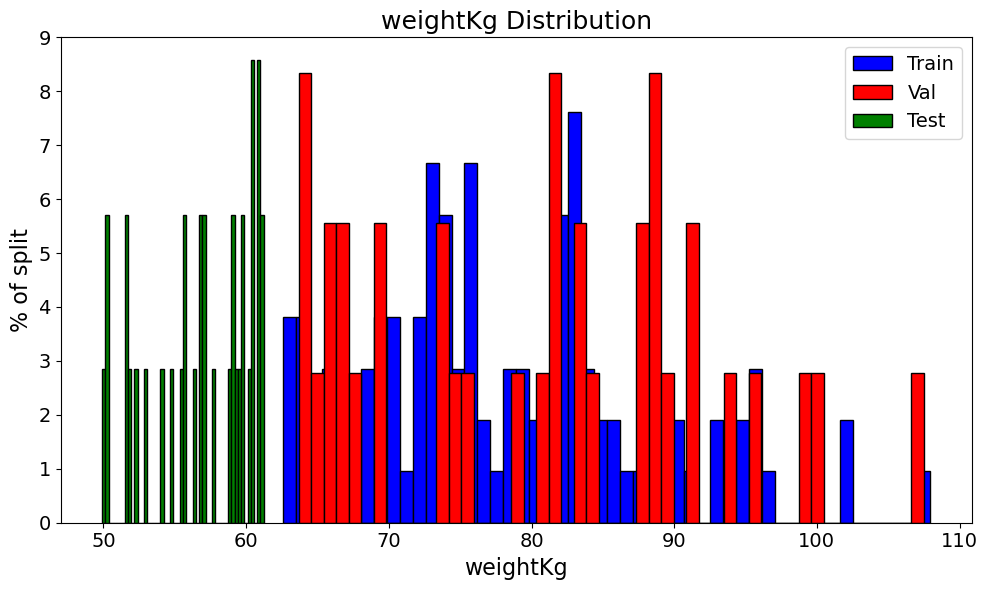

In [51]:
plot_histogram_comparison(train_df=w_train, val_df=w_val, test_df=w_test, feature="weightKg")

In [52]:
weight_dir = os.path.join(processed_path, "weight")
save_new_datasets(train=w_train, val=w_val, test=w_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=weight_dir, image_directory=processed_path)

Saved lengths to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/weight/tabular_lengths.pt
Saved labels to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/weight/labels_train.pt
Saved image paths to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/weight/image_paths_train.pt
Saved ADNI Features to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/weight/adni_features_train.csv
Saved labels to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/weight/labels_val.pt
Saved image paths to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/weight/image_paths_val.pt
Saved ADNI Features to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/weight/adni_features_val.csv
Saved labels to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/weight/labels_test.pt
Saved image paths to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data

## Shifts: Age

In [53]:
age_train, age_val, age_test = create_shifted_splits(df=relevant_df, split=[{"subjectAge": (">=", 71.5)}], split_cond="and", ratio=[115, 33, 34], con_columns=continuous_cols, cat_columns=categorical_cols, mode=1)

Shape of train df:	(107, 14)
Shape of val df:	(36, 14)
Shape of test df:	(35, 14)
Total Size: 178
Ratio -> Train: 0.6 | Val: 0.2 | Test: 0.2


In [54]:
display([i for i in age_train["subjectIdentifier"].unique() if i in age_test["subjectIdentifier"].unique()])

[]

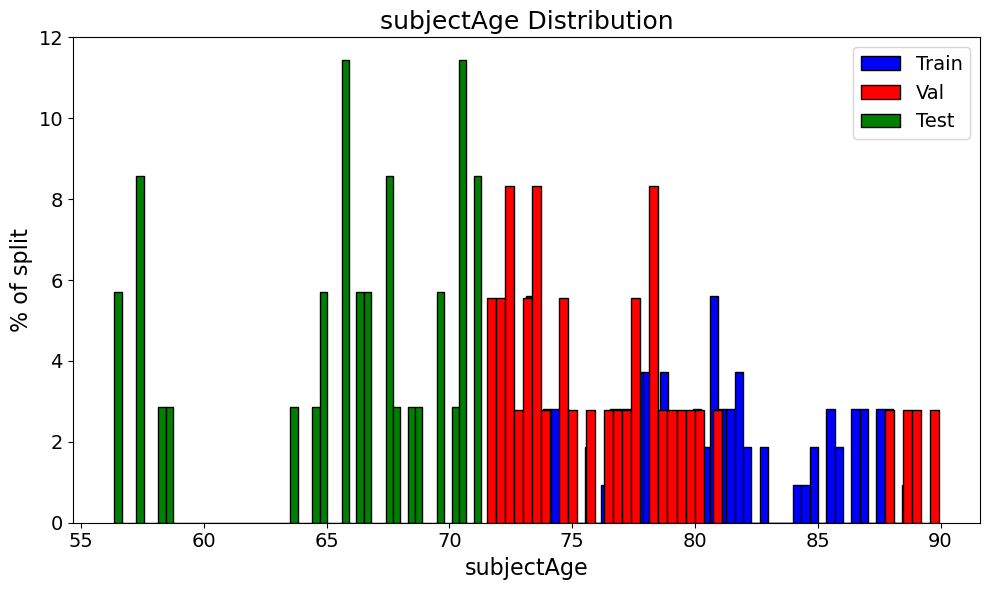

In [55]:
plot_histogram_comparison(train_df=age_train, val_df=age_val, test_df=age_test, feature="subjectAge")

In [56]:
age_dir = os.path.join(processed_path, "age")
save_new_datasets(train=age_train, val=age_val, test=age_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=age_dir, image_directory=processed_path)

Saved lengths to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/age/tabular_lengths.pt
Saved labels to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/age/labels_train.pt
Saved image paths to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/age/image_paths_train.pt
Saved ADNI Features to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/age/adni_features_train.csv
Saved labels to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/age/labels_val.pt
Saved image paths to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/age/image_paths_val.pt
Saved ADNI Features to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/age/adni_features_val.csv
Saved labels to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/age/labels_test.pt
Saved image paths to /mnt/data/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/processed_data/age/image_paths_test.pt